# Gini vs. Entropy — Interpretability Comparison

Companion to `01-data-pipeline.ipynb`. Implements the explainability/
interpretability comparison methods from `project-work/skye/idea-proposal.md`
across our three datasets (Breast Cancer Wisconsin, Heart Disease, Heart
Failure Clinical Records).

We test the three hypotheses from the idea proposal:

- **H1:** Gini produces structurally simpler trees (fewer splits) but less
  stable feature importance.
- **H2:** Entropy produces more stable, consistent feature rankings but
  deeper trees.
- **H3:** The difference is dataset-dependent.

Metrics implemented here (mirrors `code/analysis/structural.py` and
`code/analysis/stability.py`):

1. **Structural complexity:** depth, node count, leaf count, features used.
2. **Accuracy-vs-depth trade-off:** accuracy at matched depth budgets.
3. **Predictive stability:** feature-importance agreement (Kendall's Tau,
   top-k overlap) across repeated resamples.
4. **Visual comparison:** side-by-side trees at a readable depth.

## 0. Setup

In [3]:
# %pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
TEST_SIZE = 0.2

# Validated categorical pair from the project's dataviz palette: fixed
# assignment, used consistently everywhere: Gini is always blue, Entropy is
# always orange, across every chart in this notebook.
GINI_COLOR = "#2a78d6"
ENTROPY_COLOR = "#eb6834"
CRITERIA = ["gini", "entropy"]
CRITERION_COLORS = {"gini": GINI_COLOR, "entropy": ENTROPY_COLOR}

## 1. Loaders (copied from `01-data-pipeline.ipynb`)

In [4]:
NOMINAL_COLS_HD = ["cp", "restecg", "slope", "thal"]


def load_breast_cancer():
    ds = fetch_ucirepo(id=17)
    X = ds.data.features.copy()
    y = (ds.data.targets.copy().iloc[:, 0] == "M").astype(int)
    return X, y


def load_heart_disease():
    ds = fetch_ucirepo(id=45)
    X = ds.data.features.copy()
    y = (ds.data.targets.copy().iloc[:, 0] > 0).astype(int)

    X["ca"] = X["ca"].fillna(X["ca"].median())
    X["thal"] = X["thal"].fillna(X["thal"].mode().iloc[0])

    X = pd.get_dummies(X, columns=NOMINAL_COLS_HD, prefix=NOMINAL_COLS_HD)
    X = X.astype({c: int for c in X.columns if X[c].dtype == bool})
    return X, y


def load_heart_failure(exclude_time=True):
    ds = fetch_ucirepo(id=519)
    X = ds.data.features.copy()
    y = ds.data.targets.copy().iloc[:, 0]
    if exclude_time:
        X = X.drop(columns=["time"])
    return X, y


LOADERS = {
    "breast_cancer": load_breast_cancer,
    "heart_disease": load_heart_disease,
    "heart_failure": load_heart_failure,
}

datasets = {}
for name, loader in LOADERS.items():
    X, y = loader()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    datasets[name] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "feature_names": X.columns.tolist(),
    }
    print(f"{name}: train={X_train.shape}, test={X_test.shape}")

breast_cancer: train=(455, 30), test=(114, 30)
heart_disease: train=(242, 22), test=(61, 22)
heart_failure: train=(239, 11), test=(60, 11)


## 2. Train Gini & Entropy Trees (Baseline, Unconstrained Depth)

Mirrors `code/models/train.py`'s `train_gini_tree`/`train_entropy_tree`.

In [5]:
def train_tree(X_train, y_train, X_test, y_test, criterion, max_depth=None, random_state=RANDOM_STATE):
    tree = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, random_state=random_state)
    tree.fit(X_train, y_train)
    accuracy = tree.score(X_test, y_test)
    return tree, accuracy


baseline = {}
for name, d in datasets.items():
    baseline[name] = {}
    for criterion in CRITERIA:
        tree, acc = train_tree(d["X_train"], d["y_train"], d["X_test"], d["y_test"], criterion)
        baseline[name][criterion] = {"tree": tree, "accuracy": acc}
    print(f"{name}: gini acc={baseline[name]['gini']['accuracy']:.3f}  "
          f"entropy acc={baseline[name]['entropy']['accuracy']:.3f}")

breast_cancer: gini acc=0.930  entropy acc=0.956
heart_disease: gini acc=0.754  entropy acc=0.770
heart_failure: gini acc=0.717  entropy acc=0.600


## 3. Structural Complexity Comparison

Depth, leaf count, node count and number of distinct features actually used
in splits — a shallower tree using fewer features is generally considered
easier for a human to trace through (idea proposal, "Structural Complexity").

In [6]:
def structural_metrics(tree):
    """Structural complexity metrics for a single fitted tree."""
    used_features = tree.tree_.feature[tree.tree_.feature >= 0]
    return {
        "depth": tree.get_depth(),
        "n_leaves": tree.get_n_leaves(),
        "n_nodes": tree.tree_.node_count,
        "n_features_used": len(set(used_features)),
    }


structural_rows = []
for name, d in datasets.items():
    for criterion in CRITERIA:
        row = {"dataset": name, "criterion": criterion, "accuracy": baseline[name][criterion]["accuracy"]}
        row.update(structural_metrics(baseline[name][criterion]["tree"]))
        structural_rows.append(row)

structural_df = pd.DataFrame(structural_rows)
structural_df

,dataset,criterion,accuracy,depth,n_leaves,n_nodes,n_features_used
0,breast_cancer,gini,0.929825,8,24,47,14
1,breast_cancer,entropy,0.956140,7,17,33,12
2,heart_disease,gini,0.754098,9,48,95,15
3,heart_disease,entropy,0.770492,10,48,95,16
4,heart_failure,gini,0.716667,13,51,101,9
5,heart_failure,entropy,0.600000,14,50,99,9


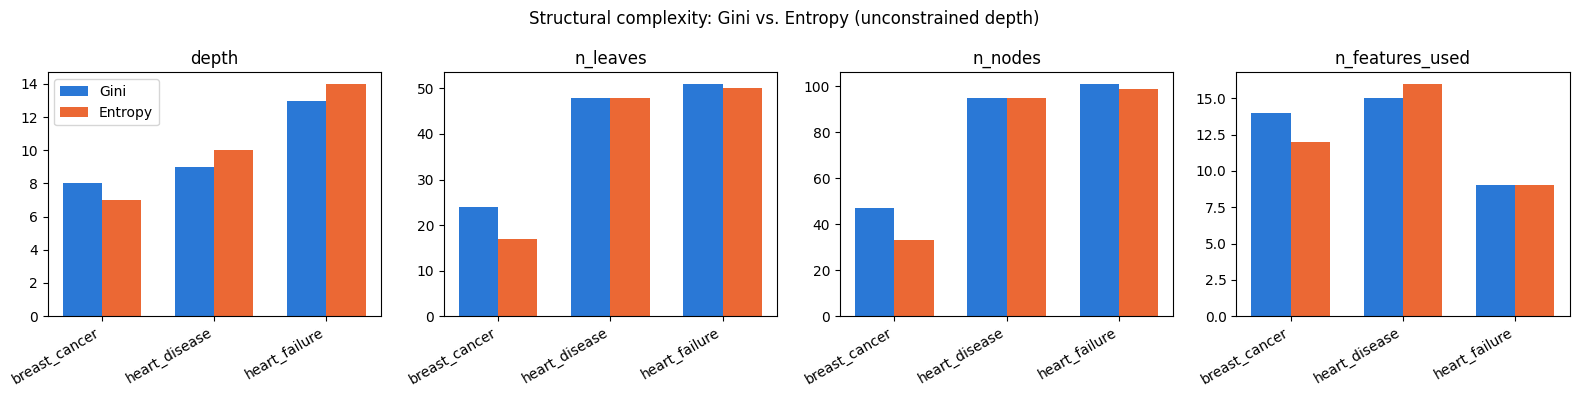

In [7]:
metrics_to_plot = ["depth", "n_leaves", "n_nodes", "n_features_used"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4), sharex=False)

dataset_names = list(datasets.keys())
x = np.arange(len(dataset_names))
width = 0.35

for ax, metric in zip(axes, metrics_to_plot):
    gini_vals = structural_df[structural_df.criterion == "gini"].set_index("dataset").loc[dataset_names, metric]
    entropy_vals = structural_df[structural_df.criterion == "entropy"].set_index("dataset").loc[dataset_names, metric]
    ax.bar(x - width / 2, gini_vals, width, label="Gini", color=GINI_COLOR)
    ax.bar(x + width / 2, entropy_vals, width, label="Entropy", color=ENTROPY_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_names, rotation=30, ha="right")
    ax.set_title(metric)

axes[0].legend()
fig.suptitle("Structural complexity: Gini vs. Entropy (unconstrained depth)")
plt.tight_layout()
plt.show()

**TODO (discussion):** does either criterion consistently produce
shallower/sparser trees across all three datasets (supports H1/H2), or does
it vary by dataset (supports H3)?

## 4. Accuracy-vs-Depth Trade-off

If one criterion reaches higher accuracy at the *same* depth budget, it's
arguably more interpretable per unit of predictive performance (idea
proposal, "Accuracy-Interpretability Tradeoff").

In [8]:
DEPTHS = [3, 5, 7, 10]

depth_rows = []
for name, d in datasets.items():
    for depth in DEPTHS:
        for criterion in CRITERIA:
            _, acc = train_tree(d["X_train"], d["y_train"], d["X_test"], d["y_test"], criterion, max_depth=depth)
            depth_rows.append({"dataset": name, "criterion": criterion, "max_depth": depth, "accuracy": acc})

depth_df = pd.DataFrame(depth_rows)
depth_df.pivot_table(index=["dataset", "max_depth"], columns="criterion", values="accuracy")

criterion                 entropy      gini
dataset       max_depth                    
breast_cancer 3          0.938596  0.903509
              5          0.956140  0.921053
              7          0.956140  0.938596
              10         0.956140  0.929825
heart_disease 3          0.803279  0.868852
              5          0.737705  0.721311
              7          0.770492  0.737705
              10         0.770492  0.754098
heart_failure 3          0.750000  0.783333
              5          0.616667  0.716667
              7          0.633333  0.733333
              10         0.633333  0.733333

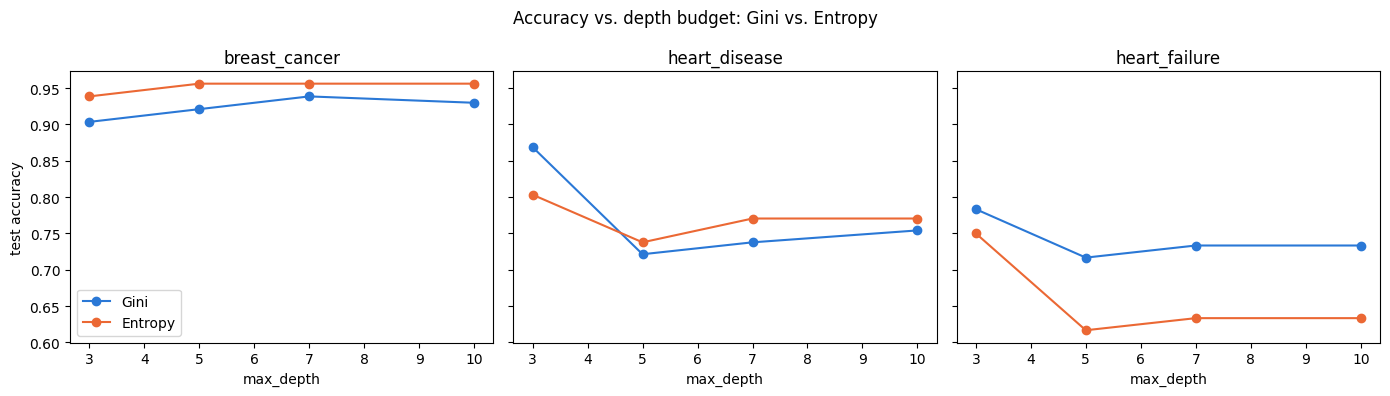

In [9]:
fig, axes = plt.subplots(1, len(dataset_names), figsize=(14, 4), sharey=True)

for ax, name in zip(axes, dataset_names):
    sub = depth_df[depth_df.dataset == name]
    for criterion in CRITERIA:
        s = sub[sub.criterion == criterion].sort_values("max_depth")
        ax.plot(s["max_depth"], s["accuracy"], marker="o", label=criterion.capitalize(),
                color=CRITERION_COLORS[criterion])
    ax.set_title(name)
    ax.set_xlabel("max_depth")

axes[0].set_ylabel("test accuracy")
axes[0].legend()
fig.suptitle("Accuracy vs. depth budget: Gini vs. Entropy")
plt.tight_layout()
plt.show()

## 5. Predictive Stability (Resampling + Kendall's Tau)

For each criterion, retrain on `N_RUNS` different random train/test splits
and record the feature-importance ranking each time. A criterion is
"stable" if the ranking barely changes across resamples — unstable trees
suggest the model (and its explanations) are fragile (idea proposal,
"Predictive Stability").

In [10]:
N_RUNS = 30
TOP_K = 5


def run_stability_experiment(X, y, criterion, n_runs=N_RUNS, top_k=TOP_K):
    """Train `n_runs` trees on different random splits; return a DataFrame of
    feature importances (rows = run, columns = feature) for one criterion."""
    rows = []
    for run in range(n_runs):
        X_tr, _, y_tr, _ = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=run, stratify=y
        )
        tree = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
        tree.fit(X_tr, y_tr)
        rows.append(tree.feature_importances_)
    return pd.DataFrame(rows, columns=X.columns)


def stability_summary(importances_df, top_k=TOP_K):
    """Given (n_runs x n_features) importances, compute:
    - mean pairwise Kendall's Tau between runs' full rankings
    - mean pairwise Jaccard overlap of each run's top-k features
    (both measured relative to run 0, which is enough to summarise agreement
    without the O(n_runs^2) pairwise cost).
    """
    reference_rank = importances_df.iloc[0].rank()
    reference_top_k = set(importances_df.iloc[0].nlargest(top_k).index)

    taus, jaccards = [], []
    for i in range(1, len(importances_df)):
        rank_i = importances_df.iloc[i].rank()
        tau, _ = kendalltau(reference_rank, rank_i)
        taus.append(tau)

        top_k_i = set(importances_df.iloc[i].nlargest(top_k).index)
        jaccard = len(reference_top_k & top_k_i) / len(reference_top_k | top_k_i)
        jaccards.append(jaccard)

    return {"mean_kendall_tau": float(np.mean(taus)), "mean_top_k_jaccard": float(np.mean(jaccards))}


stability_rows = []
importances_by_dataset_criterion = {}

for name, d in datasets.items():
    X_full = pd.concat([d["X_train"], d["X_test"]])
    y_full = pd.concat([d["y_train"], d["y_test"]])
    for criterion in CRITERIA:
        imp_df = run_stability_experiment(X_full, y_full, criterion)
        importances_by_dataset_criterion[(name, criterion)] = imp_df
        summary = stability_summary(imp_df)
        stability_rows.append({"dataset": name, "criterion": criterion, **summary})

stability_df = pd.DataFrame(stability_rows)
stability_df

,dataset,criterion,mean_kendall_tau,mean_top_k_jaccard
0,breast_cancer,gini,0.369843,0.425014
1,breast_cancer,entropy,0.312334,0.398331
2,heart_disease,gini,0.539095,0.541872
3,heart_disease,entropy,0.549104,0.532430
4,heart_failure,gini,0.644355,0.735632
5,heart_failure,entropy,0.615396,0.862069


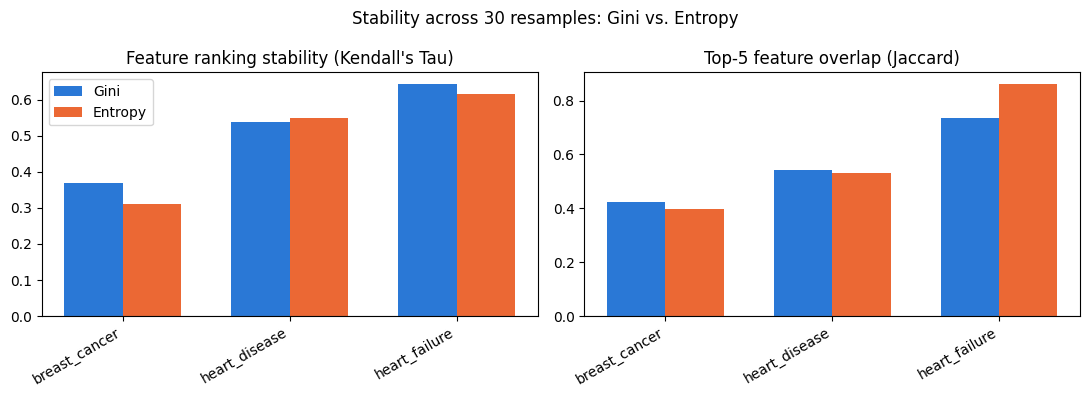

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric, title in zip(
    axes,
    ["mean_kendall_tau", "mean_top_k_jaccard"],
    ["Feature ranking stability (Kendall's Tau)", f"Top-{TOP_K} feature overlap (Jaccard)"],
):
    gini_vals = stability_df[stability_df.criterion == "gini"].set_index("dataset").loc[dataset_names, metric]
    entropy_vals = stability_df[stability_df.criterion == "entropy"].set_index("dataset").loc[dataset_names, metric]
    ax.bar(x - width / 2, gini_vals, width, label="Gini", color=GINI_COLOR)
    ax.bar(x + width / 2, entropy_vals, width, label="Entropy", color=ENTROPY_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_names, rotation=30, ha="right")
    ax.set_title(title)
    ax.axhline(0, color="grey", linewidth=0.8)

axes[0].legend()
fig.suptitle(f"Stability across {N_RUNS} resamples: Gini vs. Entropy")
plt.tight_layout()
plt.show()

**TODO (discussion):**
- Higher Kendall's Tau / Jaccard = more stable (the ranking barely changes
  across resamples). Is one criterion consistently more stable across all
  three datasets?
- This uses `random_state=run` only for the train/test split, keeping the
  tree's own `random_state` fixed — so instability here reflects sensitivity
  to *which patients happen to be in the training set*, not to the tree
  algorithm's own internal randomness (relevant with tied splits). Worth
  discussing which source of randomness the group actually cares about.

## 6. Visual Comparison (Depth-Limited for Legibility)

Full unconstrained trees are usually unreadable. Depth-3 versions make for a
fairer "can a human actually read this" comparison.

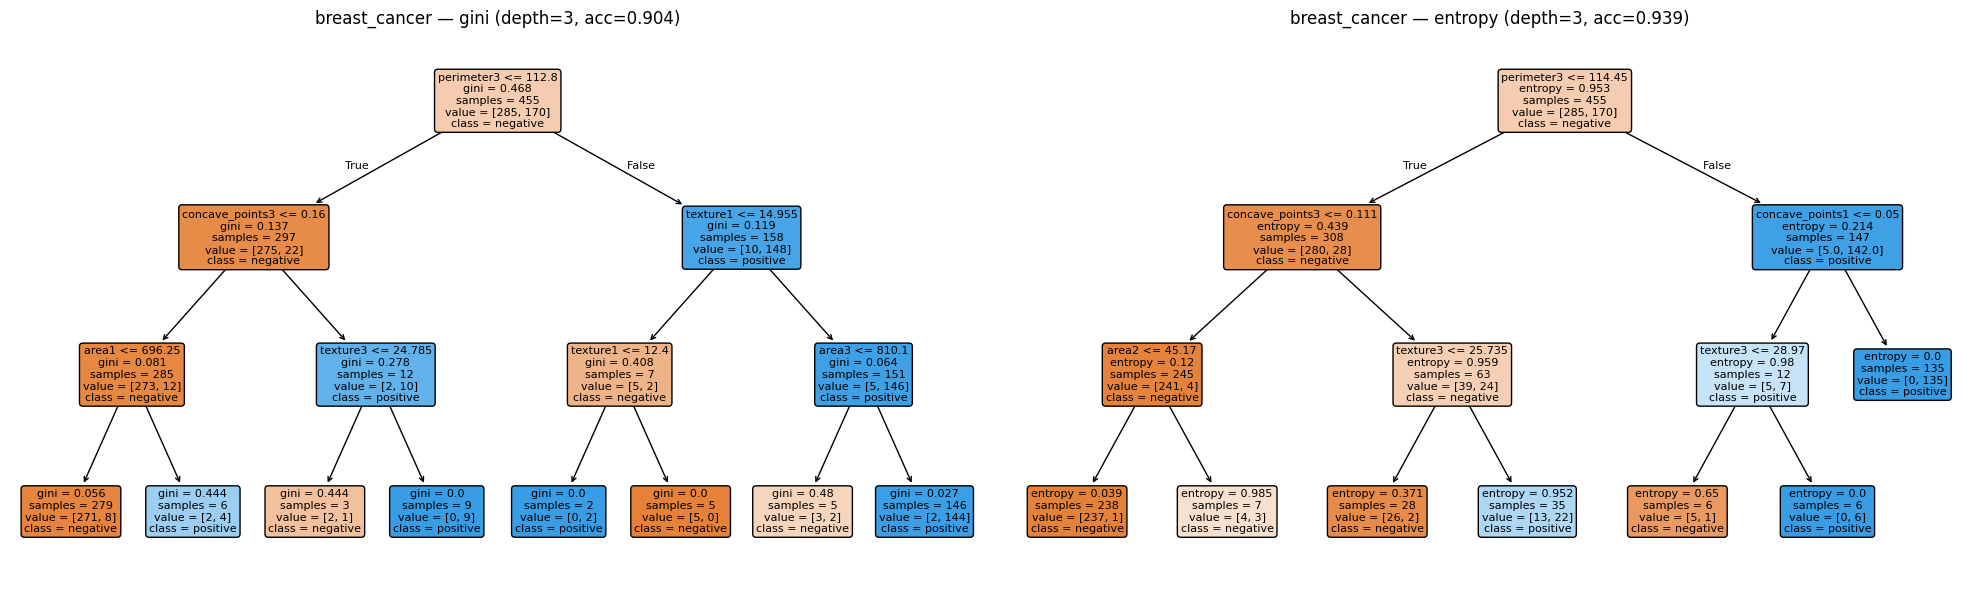

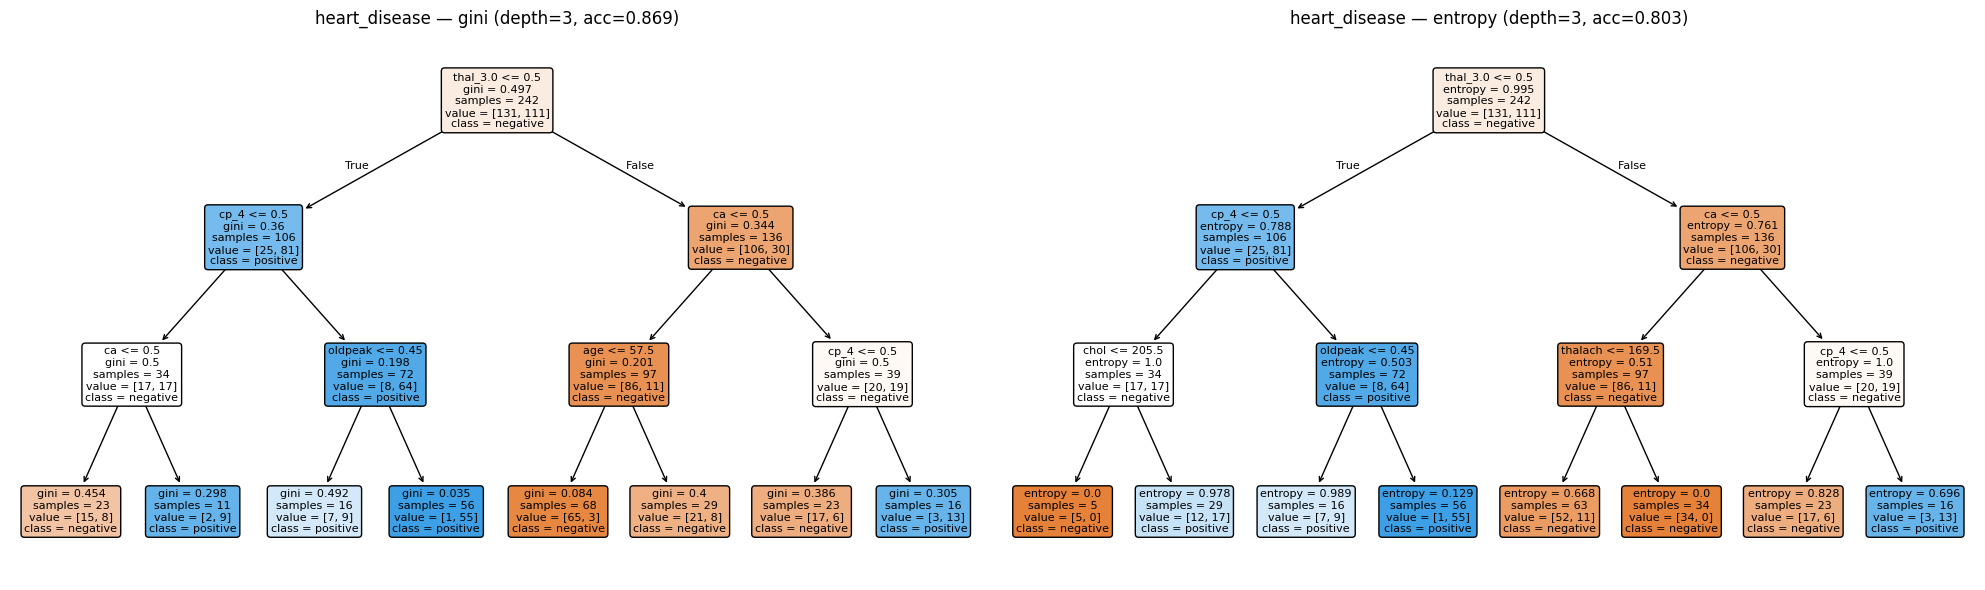

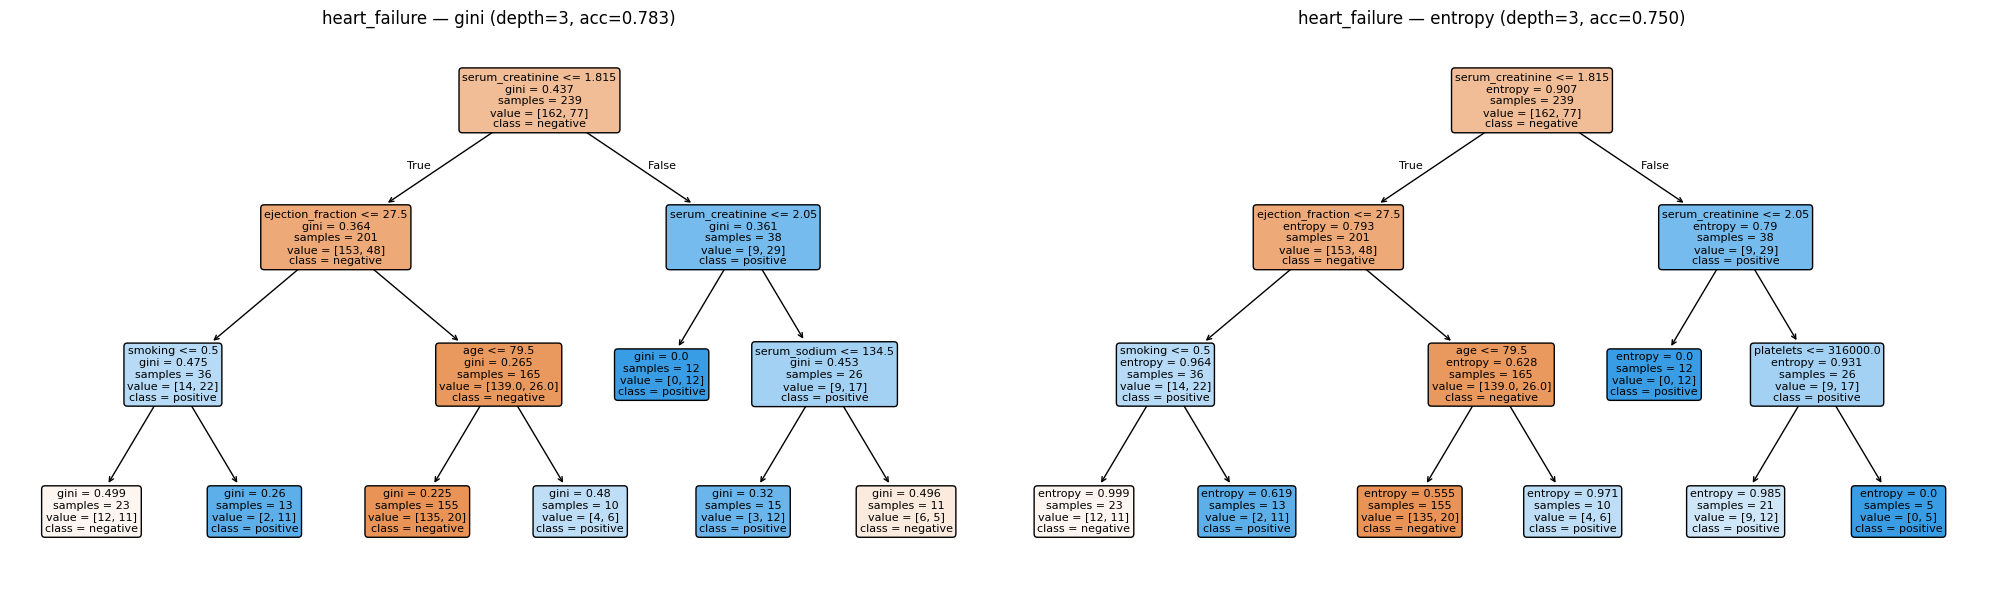

In [12]:
VIZ_DEPTH = 3

for name, d in datasets.items():
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    for ax, criterion in zip(axes, CRITERIA):
        tree, acc = train_tree(d["X_train"], d["y_train"], d["X_test"], d["y_test"], criterion, max_depth=VIZ_DEPTH)
        plot_tree(
            tree, feature_names=d["feature_names"], class_names=["negative", "positive"],
            filled=True, rounded=True, fontsize=8, ax=ax,
        )
        ax.set_title(f"{name} — {criterion} (depth={VIZ_DEPTH}, acc={acc:.3f})")
    plt.tight_layout()
    plt.show()

## 7. Combined Summary Across All Three Datasets

In [13]:
combined = structural_df.merge(stability_df, on=["dataset", "criterion"])
combined = combined[[
    "dataset", "criterion", "accuracy", "depth", "n_leaves", "n_nodes",
    "n_features_used", "mean_kendall_tau", "mean_top_k_jaccard",
]].sort_values(["dataset", "criterion"])
combined

,dataset,criterion,accuracy,depth,n_leaves,n_nodes,n_features_used,mean_kendall_tau,mean_top_k_jaccard
1,breast_cancer,entropy,0.956140,7,17,33,12,0.312334,0.398331
0,breast_cancer,gini,0.929825,8,24,47,14,0.369843,0.425014
3,heart_disease,entropy,0.770492,10,48,95,16,0.549104,0.532430
2,heart_disease,gini,0.754098,9,48,95,15,0.539095,0.541872
5,heart_failure,entropy,0.600000,14,50,99,9,0.615396,0.862069
4,heart_failure,gini,0.716667,13,51,101,9,0.644355,0.735632
